# INDUCE-seq Analysis

This notebook processes BED files from INDUCE-seq experiments to quantify DNA double strand breaks at AsiSI restriction sites on chromosome 21.

## Instructions
Take the pipeline outputs and use python code to read in, plot and interpret the data in order to determine which samples are most likely to represent the control and treated subsets. If appropriate feel free to use statistical or clustering techniques to help with interpretation.

## Questions
1.	Which of the samples are likely to be controls or treated?
2.	Are there any you are uncertain of?
3.	Can you explain the samples in the uncertain group?
4.	Of all the possible AsiSI sites described in the chr21_AsiSI_sites.t2t.bed file what is the maximum percentage observed in a single sample?

### Environment
- Python 3.11.15
- pandas
- matplotlib

In [15]:
import sys
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from time import perf_counter
from functools import wraps

### Load the summary file

In [3]:
summary_df = pd.read_csv("results/induce_seq_chr21_asisi_summary.tsv", sep="\t")

Quick check of the summary dataframe

In [4]:
summary_df.head()
summary_df.info()
summary_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sample        16 non-null     str    
 1   asisi_breaks  16 non-null     int64  
 2   total_breaks  16 non-null     int64  
 3   normalised    16 non-null     float64
dtypes: float64(1), int64(2), str(1)
memory usage: 644.0 bytes


,asisi_breaks,total_breaks,normalised
count,16.000000,16.000000,16.000000
mean,4.562500,4614.937500,1.483544
std,5.887487,2362.015085,1.683838
min,0.000000,1583.000000,0.000000
25%,0.000000,2703.750000,0.000000
50%,1.500000,4573.500000,0.769500
75%,7.750000,5835.750000,2.901925
max,18.000000,10088.000000,4.962800


## Investigation

In [5]:
summary_df.sort_values("normalised", ascending=False)

,sample,asisi_breaks,total_breaks,normalised
0,Sample11,10,2015,4.9628
5,Sample10,10,2869,3.4855
14,Sample16,18,5179,3.4756
10,Sample15,15,4716,3.1807
9,Sample9,5,1780,2.8090
6,Sample12,5,2208,2.2645
4,Sample14,7,3466,2.0196
3,Sample13,2,1583,1.2634
2,Sample3,1,3628,0.2756
1,Sample8,0,4431,0.0000


Inspection of the data suggests a clear bimodal structure: 7 samples show zero AsiSI-associated breaks (consistent with untreated controls), while 7 samples show strong enrichment (≥5 breaks), consistent with treated samples. Two samples (3 and 13) exhibit low but non-zero signal.

Sample 13 has only two AsiSI-associated breaks and also the lowest total break count across all samples, suggesting reduced sequencing depth or stochastic sampling effects may be influencing detection. Sample 3 shows a single AsiSI-associated break despite a moderate total break count, indicating low-level background signal rather than true AsiSI induction. These samples are therefore considered ambiguous and require further QC assessment (e.g. read depth distribution or alignment quality metrics). 

For downstream classification, samples were grouped using a simple threshold applied to the normalised AsiSI signal. A lambda function was used in Pandas to assign labels based on this, separating clear controls (0), uncertain low-signal samples (<2), and treated samples (≥2). 

In [ ]:
summary_df["group"] = summary_df["normalised"].apply(
    lambda x: "control" if x == 0
    else "uncertain" if x < 2
    else "treated"
)

summary_df.sort_values("normalised", ascending=False)

# Output the formatted data to csv
summary_df.sort_values(
    "normalised",
    ascending=False
).to_csv(
    "results/induce_seq_chr21_sample_classification.tsv",
    sep="\t",
    index=False
)

### Plot summary data

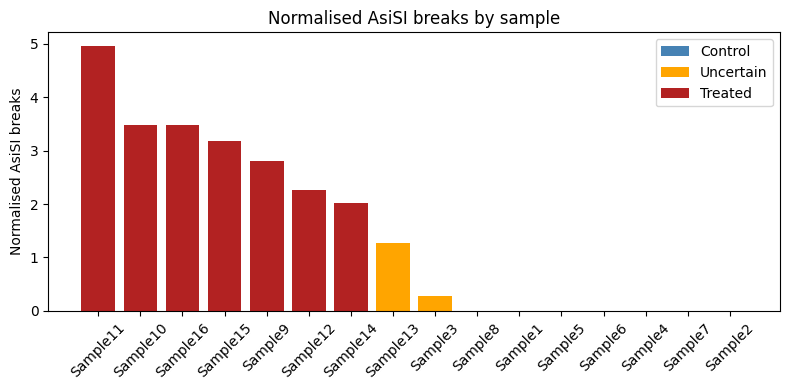

In [ ]:
plot_df = summary_df.sort_values("normalised", ascending=False)

plot_df["sample_clean"] = plot_df["sample"].str.replace("Sample", "", regex=False)

colours = {
    "control": "steelblue",
    "uncertain": "orange",
    "treated": "firebrick"
}

bar_colours = plot_df["group"].map(colours)

legend_elements = [
    Patch(facecolor="steelblue", label="Control"),
    Patch(facecolor="orange", label="Uncertain"),
    Patch(facecolor="firebrick", label="Treated")
]

plt.figure(figsize=(8,4))

plt.bar(
    plot_df["sample_clean"],
    plot_df["normalised"],
    color=bar_colours
)

plt.xticks(rotation=45)
plt.ylabel("Normalised AsiSI breaks")
plt.title("Normalised AsiSI breaks by sample")

plt.legend(handles=legend_elements)

plt.tight_layout()
# Output the pngs
plt.savefig(
    "results/bar_normalised_asisi_breaks.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Fig 1.** Normalised AsiSI-associated DNA break counts across all samples, ordered by signal intensity and coloured by inferred experimental group (control, uncertain, treated).

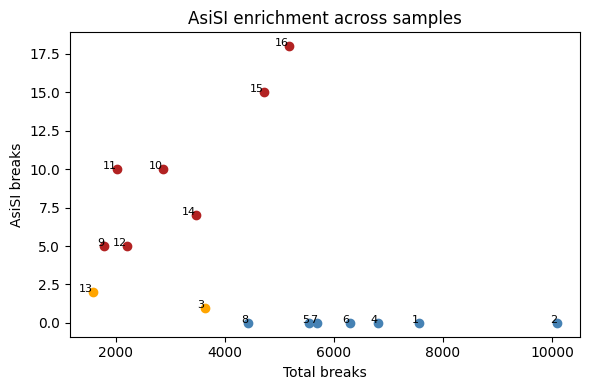

In [ ]:
plt.figure(figsize=(6,4))

for _, row in summary_df.iterrows():
    plt.scatter(
        row["total_breaks"],
        row["asisi_breaks"],
        color=colours[row["group"]]
    )

    plt.text(
        row["total_breaks"],
        row["asisi_breaks"],
        row["sample"].replace("Sample", ""),
        fontsize=8,
        ha="right"
    )

plt.xlabel("Total breaks")
plt.ylabel("AsiSI breaks")
plt.title("AsiSI enrichment across samples")

plt.tight_layout()
# Output the pngs
plt.savefig(
    "results/scatter_Asisi_enrichment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.show()

**Fig 2.** Relationship between total DNA break counts and AsiSI-associated break events per sample. Samples are coloured by inferred group classification.

 ## Which sample has the max percent of sites?
 For determining the number of sites, the intersect files contains duplicate reads at the same site - these must be collapsed to determine the number of unique sites.

In [ ]:
# Breaks file
asisi_cols = ["chrom", "start", "end"]
asisi_df = pd.read_csv(
    "data/chr21_AsiSI_sites.t2t.bed",
    sep="\t",
    header=None,
    names=asisi_cols
)
asisi_df.head()
total_asisi_sites = len(asisi_df)

print(total_asisi_sites)

71


### Add the timer function

In [ ]:


def timer(func):
    """
    Decorator to measure execution time of a function.
    """

    @wraps(func)
    def wrapper(*args, **kwargs):
        start = perf_counter()

        result = func(*args, **kwargs)

        end = perf_counter()

        print(f"[TIMER] {func.__name__}: {end - start:.3f}s")

        return result

    return wrapper

### Load in the intersected files
And use the timer to time it

In [24]:
intersect_dir = Path("results/intersected")

@timer
def load_intersect_results(intersect_dir, total_asisi_sites):

    import pandas as pd
    from pathlib import Path

    results = []

    for bed_file in Path(intersect_dir).glob("*.bed"):

        sample = bed_file.stem.split(".")[0]

        if bed_file.stat().st_size == 0:
            results.append({
                "sample": sample,
                "break_events": 0,
                "unique_sites": 0,
                "pct_sites_observed": 0
            })
            continue

        df = pd.read_csv(bed_file, sep="\t", header=None)

        break_events = len(df)

        unique_sites = df[[0,1,2]].drop_duplicates().shape[0]

        pct_sites_observed = unique_sites / total_asisi_sites * 100

        results.append({
            "sample": sample,
            "break_events": break_events,
            "unique_sites": unique_sites,
            "pct_sites_observed": pct_sites_observed
        })

    return pd.DataFrame(results)



site_df = load_intersect_results(intersect_dir, total_asisi_sites)
site_df.sort_values("pct_sites_observed", ascending=False)


[TIMER] load_intersect_results: 0.016s


,sample,break_events,unique_sites,pct_sites_observed
2,Sample11,10,6,8.450704
6,Sample15,15,6,8.450704
5,Sample14,7,5,7.042254
7,Sample16,18,5,7.042254
1,Sample10,10,4,5.633803
15,Sample9,5,4,5.633803
3,Sample12,5,3,4.225352
4,Sample13,2,2,2.816901
9,Sample3,1,1,1.408451
0,Sample1,0,0,0.000000


# Questions

1.	Which of the samples are likely to be controls or treated?
- treated: 9, 10, 11, 12, 14, 15, 16
- control: 1, 2, 4, 5, 6, 7, 8
    
2.	Are there any you are uncertain of?
- Yes, 3 and 13 

3.	Can you explain the samples in the uncertain group?
- Sample 13 has 2 asisi breaks and the lowest overall total breaks, so maybe this is an artifact of a poorly sequenced sample or chromatin accessibility. Sample3 has only 1 asisi break and a good number of total breaks, suggesting this is likely noise. I would consider these samples uncertian until a further investigation was performed (fastQC or check the bams with IGV?)

4.	Of all the possible AsiSI sites described in the chr21_AsiSI_sites.t2t.bed file what is the maximum percentage observed in a single sample?
- The maximum percent is 8.45% (6 sites of 71), observed in samples 11 and 15. 

## Further thoughts
- For larger datasets, a data-driven approach could replace the fixed threshold used here. Unsupervised methods such as k-means or hierarchical clustering could be applied to assess whether samples naturally separate into distinct control and treated groups based on AsiSI enrichment and overall break profiles.
- A site-level analysis would provide additional biological resolution. Key questions include:
    - Are specific AsiSI sites consistently driving the observed signal across treated samples?
    - Do site-level patterns reflect chromatin accessibility or cell-type–specific regulation?
    - Are certain sites frequently detected across all samples, suggesting constitutive breakage or mapping bias?
    - Dimensionality reduction approaches (e.g. PCA or UMAP) could be used to explore whether samples or AsiSI sites form distinct clusters beyond simple metrics, potentially revealing substructure not captured by summary statistics.
- Statistical testing could be applied to formally assess whether the difference in AsiSI enrichment between control and treated cohorts is significant.
- A deeper investigation of the “uncertain” samples (e.g. Sample 3 and 13) is warranted to determine whether their intermediate signal reflects technical artefacts (low sequencing depth, mapping quality, library complexity) or true biological variation in AsiSI activity.
